In [1]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random

In [7]:
coo=np.array([[ 1.885,1.885,0.   ],
     [ 0.,     0.,     0.   ],
     [ 0.,     3.77,   0.   ],
     [ 3.77,   0.,     0.   ],
     [ 3.77,   3.77,   0.   ],
     [-1.885,  1.885,  0.   ],
     [ 1.885, -1.885,  0.   ],
     [ 1.885,  5.655,  0.   ],
     [ 5.655,  1.885,  0.   ],
    [-1.885,  5.655,  0.   ],
    [ 5.655, -1.885,  0.   ],
    [ 5.655,  5.655,  0.   ],
    [ 0.,     7.54,   0.   ],
    [ 3.77,   7.54,   0.   ],
    [ 7.54,   0.,     0.   ],
    [ 7.54,   3.77,   0.   ],
    [ 1.885,  9.425,  0.   ]])
atom=Atoms(positions=coo)
view(atom)

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [2]:
%matplotlib widget

In [3]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [4]:
#gauss
#making lattice
from tqdm.auto import tqdm
def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    lattice=np.round(lattice-mid_position,6)
    return order_pos(lattice)
def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n_max,n_max,n_max,num_atoms)
def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    times=random.randint(1,3)
    #this is too strong
    while num_points<num_atoms*3:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

# def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
#     num_lattice=max_num_atoms//2
#     n_max=int(np.ceil(np.cbrt(num_lattice)))
#     num_points=0
#     lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
#     indices=[]
#     lattice=empty_lattice(lc,n1,n2,n3,mean_position)
#     num_points=len(lattice)
#     genome=np.zeros(len(lattice_big))
#     for i in range(num_atoms):
#         indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-3),axis=1))[0])
#     for i in indices:
#         genome[i]=1
#     return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-5),axis=1))[0])
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        #genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    assert(len(set(parameters))==len(parameters))
    return generations#,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    # print(f"fitness_genome={len(np.where(genome==1)[0])}")
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    # print(f"fitness={np.sum((true_dis-pred_dis)**2)}")
    #minimize the difference
    # difference=np.abs(true_dis-pred_dis)
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    # print(f"ranking={fitness_values}")
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    # print(f"parents={len(population)}")
    while index<tol:
        # print(i)
        # print(f"prob={threshold},{prob[i]}")
        i=random.randint(0,len(population)-1)
        index+=1
        # print(f"fitness_prob={prob[i]}")
        if random.uniform(0,1)<=prob[i]:
            
            # print("pass!")
            return list(population[i])
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    # print(f"ranking={fitness_ranking}")
    R=len(fitness_ranking)
    lamb=np.log(10)/(R-1)
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    # print(f"normalized_p={p}")
    return (p-np.min(p))/(np.max(p)-np.min(p))
    
# def cross_mutation(lc,parent1,parameters1,parent2,parameters2,mutation_rate=0.1,max_num_atoms=100):
#     n=0
#     parents=[]
#     params=[]
#     while n<2:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.ceil((parameters1[0]*x1+parameters2[0]*x2)))
#         n2_offspring=int(np.ceil(parameters1[1]*x1+parameters2[1]*x2))
#         n3_offspring=int(np.ceil(parameters1[2]*x1+parameters2[2]*x2))
#         atoms_offspring=int(np.ceil(parameters1[3]*x1+parameters2[3]*x2))
#         random_mutation=random.random()
#         if random_mutation<mutation_rate:
#             atoms_offspring=int(np.ceil(atoms_offspring+random_mutation*atoms_offspring))
#         parent,parameter=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         if parameter not in params:
#             parents.append(parent)
#             params.append(parameter)
#             n+=1 
#     return parents,params

# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     if random.random()<cross_over_rate:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent1,parameter1=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent2,parameter2=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         return parent1,parent2,parameter1,parameter2
#     else:
#         return parent1,parent2,parameter1,parameter2
def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    parent1=np.array(parent1)
    parent2=np.array(parent2)
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,[0,0,0],lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,[0,0,0],lc,max_num_atoms)
        parent1_up,parent1_down=np.array(parent1_up),np.array(parent1_down)
        parent2_up,parent2_down=np.array(parent2_up),np.array(parent2_down)
        parent1_get=parent1_up+parent2_down
        parent2_get=parent2_up+parent1_down
        parent1_get[parent1_get>1]=1
        parent2_get[parent2_get>1]=1
        if len(np.where(parent1_get==1)[0])<12 or len(np.where(parent2_get==1)[0])<12:
            return parent1,parent2
        else:
            return parent1_get,parent2_get
    else:
        return parent1,parent2
# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     num_atom1=parameter1[3]
#     num_atom2=parameter2[3]
#     min_num=min(num_atom1,num_atom2)

#     if random.random()<cross_over_rate:
#         crossover_point1=random.randint(1,min_num)
#         # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
#         # print(parent1)
#         # print(parent2)
#         # swith=random.choice([0,1])
#         return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:],parameter1,parameter2
#         # if swith==0:
#         #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
#         # if swith==1:
#         #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
#     else:
#         return parent1,parent2,parameter1,parameter2
def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    num_atoms=len(np.where(np.array(genome)==1)[0])
    if mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
    # elif mr>1/2*mutation_rate :
    #     genome_update=np.zeros(len(genome))
    #     particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    #     particle=np.array(particle)
    #     dist=np.round(cdist([np.mean(particle,axis=0)],particle),6)
    #     dist_dict=Counter(dist[0])
    #     renum=0
    #     while len(np.where(np.array(genome_update)==1)[0])<5 and renum<5:
    #         atom_index=np.random.randint(1,len(particle)-1)
    #         theta=random.uniform(0,np.pi)
    #         phi=random.uniform(0,2*np.pi)
    #         # print('no good 2')
    #         # if renum==0:
    #         #     # print("no good 2")
    #         genome_update=atom_trancate_arbi(genome,theta,phi,particle[atom_index][0],particle[atom_index][1],particle[atom_index][2],lc,max_num_atoms)
    #         renum+=1
    #         # print(len(np.where(np.array(genome_update)==1)[0]))
    #     if renum==5:
    #         genome_update=genome
    # elif mr>1/2*mutation_rate:
    #     genome_update = ini_population(lc=lc,
    #                             population_size=1,
    #                             max_num_atoms=max_num_atoms,
    #                             num_atoms=num_atoms)[0][0]
    else:
        genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
    return np.array(genome_update)
    

def atom_cut_up_down_center(genome,theta,phi,center,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    # center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        else:
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    
    # print(f"1={len(genome_recon)}")
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    
    # print(center)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<num_atoms//3:
        
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,x0,y0,z0,lc,max_num_atoms):
    center=[x0,y0,z0]
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<num_atoms//3:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,shell,lc,max_num_atoms):
    encodes=genome.copy()
    atom_num=len(np.where(encodes==1)[0])
    CN_steps=[]
    index_particle=[]
    zero_dict=dict()
    control=0
    while control<100:
        CNs1=[]
        dis1=[]
        index_particle=[]
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        for i in  range(len(big_lattice)):
            if encodes[i]==1:
                CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  dis<=np.round(np.sqrt(2)/2*lc,4) and CN1>4: 
                    index_particle.append(i)
                else:
                    encodes[i]=0
        
        for i in range(len(big_lattice)):     
            if encodes[i]==0:
                CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*lc,4):
                    zero_dict[i]=CN0
        zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
        residual=atom_num-len(index_particle)
        for i in range(residual):
            encodes[list(zero_dict.keys())[i]]=1
        # print(f"particle {j}")
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
        _,_,CN_ave=getCN_dis_N(atom,shell)
        control+=1
        CN_steps.append(CN_ave)
        if control>10:
            if CN_steps[-1]-CN_steps[-2]<1e-3:
                break
    return encodes
def remove_CN(genome,lc,max_num_atoms):
    encodes=genome.copy()
    indices=np.where(encodes==1)[0]
    atom_num=len(np.where(encodes==1)[0])
    particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
    for i in range(len(indices)):
        CN,dis=getCN_dis_Oneshell(particle,big_lattice[indices[i]],1,thickness=0.1)
        if CN<4 or dis>np.round(np.sqrt(2)/2*lc,4):
            encodes[indices[i]]=0
    return encodes
    


def genetic_algorithm():
    #1. set up parameters
    max_num_atoms=200
    generations=30
    population_size=300
    lc=3.77
    mutation_rate=0.2
    cross_over_rate=0.6
    shell=1
    descriptors={#"surface ratio": 1,
                  "flatten": 0.7,
                  "diameter_longest":10
                # "CN1":8,
                # "CN2":4,
                # "CN3":10,
                # "CN4":6

    }
    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations=ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
        # residual=population_size-len(populations)
        # if residual>0:
        #     add=ini_population(lc=lc,
        #                         population_size=residual,
        #                         max_num_atoms=max_num_atoms,
        #                         num_atoms=None)
        #     populations.extend(add)
        # print(f"populations={len(populations)}")
        # print(populations)
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1=parents(populations,fitness_values)
            parent2=parents(populations,fitness_values)
            # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            #children1=convex_particle(children1,shell,lc,max_num_atoms)
            #children2=convex_particle(children2,shell,lc,max_num_atoms)
            # children1=remove_CN(children1,lc,max_num_atoms)
            # children2=remove_CN(children2,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        fitness_values=np.array(fitness_values)
        best_fitness=np.min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        # print(np.where(fitness_values==best_fitness)[0][0])
        best_predict=predict_values[np.where(fitness_values==best_fitness)[0][0]]
        best_index=np.where(fitness_values==best_fitness)[0][0]
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        truncate_func=np.percentile(fitness_values,90)
        # print(fitness_values)
        # print(np.where(fitness_values<truncate_func)[0][0])
        # print(f"truncate_func={truncate_func}")
        # populations=[new_populations[i] for i in np.where(fitness_values<truncate_func)[0]]
        #[6]. early stopping
        if generation>10:
            error=fitness_record[generation]-fitness_record[generation-1]
            if error<1e-4:
                break
    #4. record the best solution
    best_index=np.where(fitness_values==best_fitness)[0][0]
    # print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random


In [6]:
best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'flatten': 0.7, 'diameter_longest': 10}


KeyboardInterrupt: 

In [40]:
index_best=np.where(np.array(best_solution)==1)[0]
index_best

NameError: name 'best_solution' is not defined

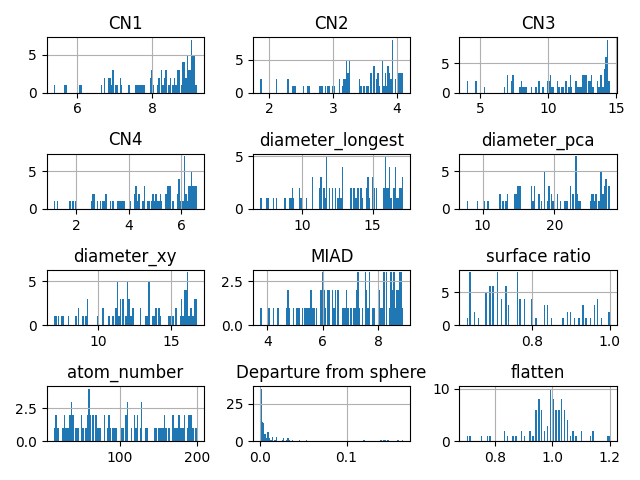

In [33]:
particles_descriptors=[]
bas=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [34]:
final_index=np.where(fitness_values<np.percentile(fitness_values,50))[0]

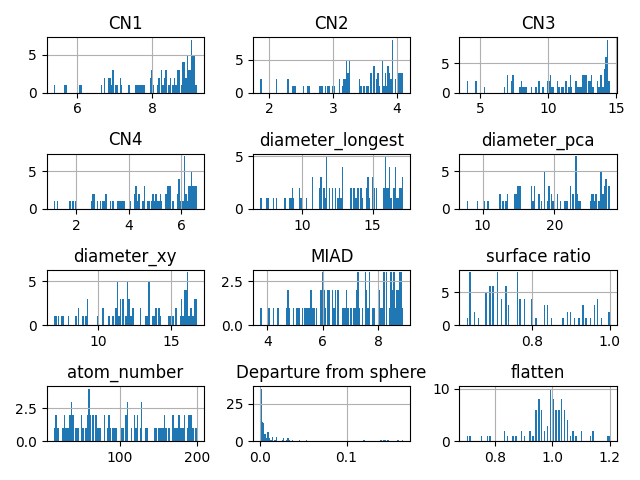

In [35]:
particles_descriptors=[]
bas=[]
for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

# Test

## 1. view particles

In [72]:
view(last_atom_list[7])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

## 2. initial condition

In [159]:
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    times=random.randint(1,3)
    #this is too strong
    while num_points<num_atoms*3:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)
def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    
    return genome
def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)



In [135]:
genome_collect=[]
particle_collect=[]
particles_descriptors=[]
atom_collect=[]
parameters_collect=[]
for i in range(1000):
    genome,parameters=particles_encode_gen(3.77,max_num_atoms=200)
    parameters_collect.append(parameters)
    genome_collect.append(genome)
    particle,lattice=recon_coordfromcodes(genome,3.77,200)
    particle_collect.append(particle)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    particles_descriptors.append(descriptor_table(atom))
    atom_collect.append(atom)
pdes=pd.DataFrame(particles_descriptors)
# view(Atoms(positions=particle,symbols=['Pt']*len(particle)))


c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\ase\atoms.py:1305: RuntimeWarning: invalid value encountered in divide
  com = masses @ self.positions / masses.sum()
d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\GA_nano_generator\shape_proj_util\geo_tools\geometry.py:245: RuntimeWarning: invalid value encountered in scalar divide
  zeta=((I[2]-I[1])**2+(I[1]-I[0])**2+(I[0]-I[2])**2)/(I[0]**2+I[1]**2+I[2]**2)
d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\GA_nano_generator\shape_proj_util\geo_tools\geometry.py:246: RuntimeWarning: invalid value encountered in scalar divide
  eta=(2*I[1]-I[0]-I[2])/I[2]
c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in

ValueError: zero-size array to reduction operation maximum which has no identity

In [157]:
genome,parameters=particles_encode_gen(3.77,max_num_atoms=200)
genome

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [143]:
pdes[pdes["CN4"]>6]

,CN1,CN2,CN3,CN4,diameter_longest,diameter_pca,diameter_xy,MIAD,surface ratio,atom_number,Departure from sphere,flatten
0,8.95,3.77,13.65,6.10,15.95,25.45,15.95,8.07,0.71,147,0.003065,0.96
1,9.09,4.06,14.36,6.41,17.04,27.26,16.60,8.78,0.64,191,0.000815,1.03
2,9.05,4.04,14.28,6.34,16.55,26.42,16.00,8.71,0.65,186,0.000379,0.98
3,9.06,4.05,14.30,6.38,16.43,26.20,15.99,8.74,0.64,188,0.000000,1.00
6,9.13,3.93,14.40,6.59,16.64,26.81,16.62,8.59,0.68,180,0.000645,1.02
23,8.91,3.78,13.55,6.04,15.72,25.88,15.63,7.99,0.71,143,0.001387,0.98
24,8.97,3.95,14.13,6.18,16.16,26.52,16.01,8.48,0.70,171,0.000386,1.01
26,9.04,4.02,14.26,6.33,16.60,26.55,16.06,8.68,0.65,184,0.000650,0.99
27,9.03,4.02,14.24,6.29,16.61,26.39,16.17,8.65,0.66,182,0.000610,1.00
29,8.90,3.91,13.85,6.10,16.01,24.72,15.78,8.27,0.73,158,0.002390,0.97


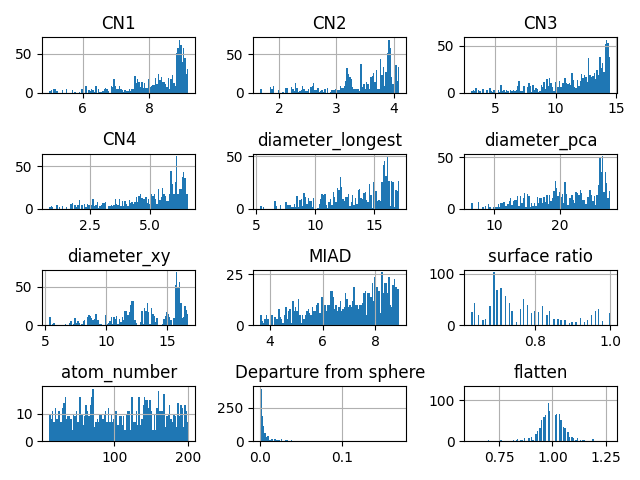

In [10]:
pdes.hist(bins=100)
plt.tight_layout()

In [11]:
view(atom_collect[968])

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

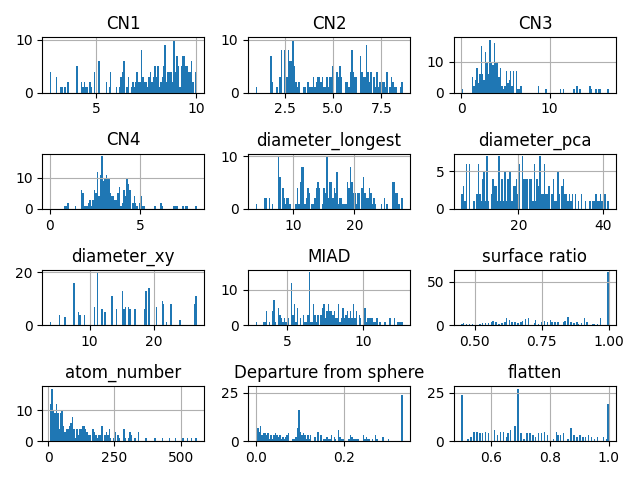

In [12]:
import shape_proj_util.geo_tools.convenient_datasoup as cds
data=cds.particle_database(element="Pt")
data.predefine_data(lattice_par=3.77)
regular_atom=[]
for i in range(len(data.shape_all)):
    regular_atom.append(data.shape_all[i].atom_obj)
regular_atom_descriptors=[]
for i in range(len(regular_atom)):
    regular_atom_descriptors.append(descriptor_table(regular_atom[i]))
pdes_regular=pd.DataFrame(regular_atom_descriptors)
pdes_regular.hist(bins=100)
plt.tight_layout()

In [13]:
len(pdes_regular[pdes_regular["atom_number"]<300])


210

In [14]:
np.mean(regular_atom[100].positions,axis=0)

array([-3.57491814e-16, -9.32587341e-17, -2.50000000e-04])

In [15]:
mean_position=np.mean(lattice,axis=0)

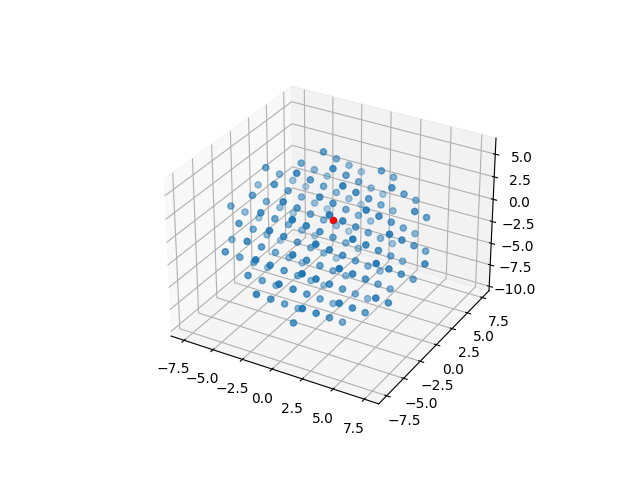

In [16]:
import matplotlib.pyplot as plt
import numpy as np
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(particle[:,0],particle[:,1],particle[:,2])
ax.scatter(mean_position[0],mean_position[1],mean_position[2],c='r')

## 3. truncate function

In [15]:
def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    # print(center)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
    trancate_particle=np.array(trancate_particle)
    trancate_particle=particle_shift_zerocenter(trancate_particle,big_lattice)
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    return genome_recon

def particle_shift_zerocenter(particle,big_crystal):
    particle_mean=np.mean(particle,axis=0)
    particle_shift=particle-particle_mean
    index=[]
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle_shift[i],big_crystal,rtol=1),axis=1))[0])
    return np.array(big_crystal[index])
    
def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1),axis=1))[0])
    # print(index)
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


In [16]:
theta=random.uniform(0,np.pi)
phi=random.uniform(0,2*np.pi)
index=1
view(ini_atom_list[index])

NameError: name 'ini_atom_list' is not defined

In [ ]:
genome1=encode_fromcoord(ini_atom_list[index].positions,3.77,200)
up1,down1=atom_cut_up_down_center(genome1,theta,phi,[0,0,0],3.77,200)
particle_up1,_=recon_coordfromcodes(up1,3.77,200)
particle_down1,_=recon_coordfromcodes(down1,3.77,200)
genometruncate1=atom_trancate_center(genome1,theta,phi,3.77,200)
particle1,_=recon_coordfromcodes(genometruncate1,3.77,200)
# view(Atoms(positions=particle1,symbols=['Pt']*len(particle1)))
genome2=encode_fromcoord(ini_atom_list[index+1].positions,3.77,200)
up2,down2=atom_cut_up_down_center(genome2,theta,phi,[0,0,0],3.77,200)
particle_up2,_=recon_coordfromcodes(up2,3.77,200)
particle_down2,_=recon_coordfromcodes(down2,3.77,200)
genometruncate2=atom_trancate_center(genome2,theta,phi,3.77,200)
particle2,_=recon_coordfromcodes(genometruncate2,3.77,200)
# view(Atoms(positions=particle2,symbols=['Pt']*len(particle2)))

NameError: name 'ini_atom_list' is not defined

In [46]:
combine1=genometruncate1+genometruncate2
combine1[combine1>1]=1
particle_combine1,_=recon_coordfromcodes(combine1,3.77,200)
view(Atoms(positions=particle_combine1,symbols=['Pt']*len(particle_combine1)))

combine2=np.abs(genometruncate1-genometruncate2)+genometruncate1
combine2[combine2>1]=1
particle_combine2,_=recon_coordfromcodes(combine2,3.77,200)
view(Atoms(positions=particle_combine2,symbols=['Pt']*len(particle_combine2)))

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

NameError: name 'particle_up2' is not defined

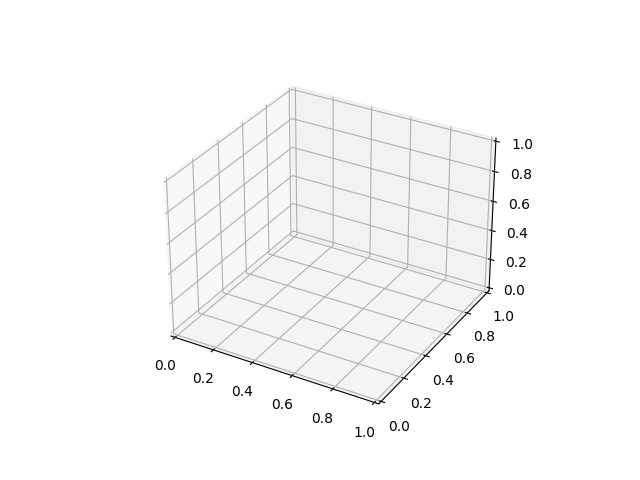

In [17]:
import matplotlib.pyplot as plt
import numpy as np
ax = plt.figure().add_subplot(projection='3d')
# ax.scatter(particle1[:,0],particle1[:,1],particle1[:,2],'b')
# ax.scatter(particle2[:,0],particle2[:,1],particle2[:,2],color='orange',alpha=0.8)
# ax.scatter(mean_position[0],mean_position[1],mean_position[2],c='r')
# ax.scatter(particle_combine1[:,0],particle_combine1[:,1],particle_combine1[:,2],c='g')
# ax.scatter(particle_combine2[:,0],particle_combine2[:,1],particle_combine2[:,2],c='r')
ax.scatter(particle_up2[:,0],particle_up2[:,1],particle_up2[:,2],c='g')
# ax.scatter(particle_down2[:,0],particle_down2[:,1],particle_down2[:,2],c='y')
# ax.scatter(particle_up1[:,0],particle_up1[:,1],particle_up1[:,2],c='r')
ax.scatter(particle_down1[:,0],particle_down1[:,1],particle_down1[:,2],c='b')



## 4. crossover

In [164]:
def atom_cut_up_down_center(genome,theta,phi,center,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    # center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        else:
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    trancate_up_particle=np.array(trancate_up_particle)
    trancate_down_particle=np.array(trancate_down_particle)
    trancate_up_particle=particle_shift_zerocenter(trancate_up_particle,big_lattice)
    trancate_down_particle=particle_shift_zerocenter(trancate_down_particle,big_lattice)
    # print(trancate_up_particle,trancate_down_particle)
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    
    # print(f"1={len(genome_recon)}")
    return np.array(genome_up_recon),np.array(genome_down_recon)

def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    parent1=np.array(parent1)
    parent2=np.array(parent2)
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,[0,0,0],lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,[0,0,0],lc,max_num_atoms)
        parent1_up,parent1_down=np.array(parent1_up),np.array(parent1_down)
        parent2_up,parent2_down=np.array(parent2_up),np.array(parent2_down)
        parent1_get=parent1_up+parent2_down
        parent2_get=parent2_up+parent1_down
        parent1_get[parent1_get>1]=1
        parent2_get[parent2_get>1]=1
        if len(np.where(parent1_get==1)[0])<12 or len(np.where(parent2_get==1)[0])<12:
            return parent1,parent2
        else:
            return parent1_get,parent2_get
    else:
        return parent1,parent2



max_num_atoms=200
generations=30
population_size=300
lc=3.77
mutation_rate=0.2
cross_over_rate=0.6
shell=1
descriptors={#"surface ratio": 1,
                "flatten": 0.7,
                "diameter_longest":10
            # "CN1":8,
            # "CN2":4,
            # "CN3":10,
            # "CN4":6

}
print(descriptors)
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big=empty_lattice(lc,n_max,n_max,n_max)
fitness_record=[]
best_particle=[]
#3. calculate fitness for populations
fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in genome_collect]
#4. start iteration
# for generation in tqdm(range(generations)):
    # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
    #(1). generate new populations
new_populations = []
# residual=population_size-len(populations)
# if residual>0:
#     add=ini_population(lc=lc,
#                         population_size=residual,
#                         max_num_atoms=max_num_atoms,
#                         num_atoms=None)
#     populations.extend(add)
# print(f"populations={len(populations)}")
# print(populations)
#check duplicates, if duplicates exist, then generate a new structure
for _ in range(population_size//2):
    #[1]. find parents from populations based on fitness values
    # print(len(populations),len(parameters),len(fitness_values))
    parent1=parents(genome_collect,fitness_values)
    parent2=parents(genome_collect,fitness_values)
    # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
    # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
    #[2]. crossover and mutation to generate offsprings
    children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
    # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
    
    # children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
    # children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
    #children1=convex_particle(children1,shell,lc,max_num_atoms)
    #children2=convex_particle(children2,shell,lc,max_num_atoms)
    # children1=remove_CN(children1,lc,max_num_atoms)
    # children2=remove_CN(children2,lc,max_num_atoms)
    new_populations.extend([children1,children2])
last_list=[]
for i in range(len(new_populations)):
    particle,_=recon_coordfromcodes(new_populations[i],lc,max_num_atoms)
    last_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))

{'flatten': 0.7, 'diameter_longest': 10}


c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\ase\atoms.py:1305: RuntimeWarning: invalid value encountered in divide
  com = masses @ self.positions / masses.sum()
d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\GA_nano_generator\shape_proj_util\geo_tools\geometry.py:245: RuntimeWarning: invalid value encountered in scalar divide
  zeta=((I[2]-I[1])**2+(I[1]-I[0])**2+(I[0]-I[2])**2)/(I[0]**2+I[1]**2+I[2]**2)
d:\sbu-PHD\Ph.D. project\project shape-changing\notebook\test12_particle generator-II\GA_nano_generator\shape_proj_util\geo_tools\geometry.py:246: RuntimeWarning: invalid value encountered in scalar divide
  eta=(2*I[1]-I[0]-I[2])/I[2]
c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaife\anaconda3\envs\NN_work\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in

ValueError: zero-size array to reduction operation maximum which has no identity

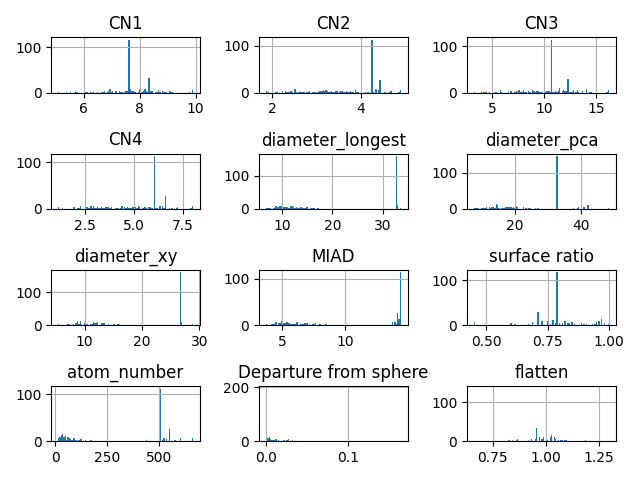

In [61]:
particles_descriptors=[]
bas=[]
for i in range(len(last_list)):
    particles_descriptors.append(descriptor_table(last_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [51]:
view(last_list[0])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

## 4. Step by step analysis

In [7]:
max_num_atoms=200
generations=30
population_size=100
lc=3.77
mutation_rate=0.1
cross_over_rate=0.5
shell=1
descriptors={#"surface ratio": 1,
                "flatten": 0.7,
                "diameter_longest":25

}
print(descriptors)
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big,_=empty_lattice(lc,n_max,n_max,n_max)

#2. initialization of populations
populations,parameters=ini_population(lc=lc,
                            population_size=population_size,
                            max_num_atoms=max_num_atoms,
                            num_atoms=None)
# populations_ini_mute=[]
# for i in range(len(populations)):
#     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
ini_population_record=populations.copy()
fitness_record=[]
best_particle=[]
fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]

{'flatten': 0.7, 'diameter_longest': 25}


In [38]:
new_populations = []
generation=5  
#check duplicates, if duplicates exist, then generate a new structure
for _ in range(population_size//2):
    #[1]. find parents from populations based on fitness values
    # print(len(populations),len(parameters),len(fitness_values))
    parent1,parameters1=parents(populations,parameters,fitness_values)
    parent2,parameters2=parents(populations,parameters,fitness_values)
    # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
    # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
    #[2]. crossover and mutation to generate offsprings
    children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
    # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
    
    children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
    children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
    #children1=convex_particle(children1,shell,lc,max_num_atoms)
    #children2=convex_particle(children2,shell,lc,max_num_atoms)
    children1=remove_CN(children1,lc,max_num_atoms)
    children2=remove_CN(children2,lc,max_num_atoms)
    new_populations.extend([children1,children2])

#(2). calculate fitness for new populations and obtain the predicted descriptors
fitness_values=[]
predict_values=[]
for genome in new_populations:
    # print(f"genome={genome}")
    fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
    fitness_values.append(fitness_cal[0])
    predict_values.append(fitness_cal[1])
# clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
#(3). find the best solution
#[1]. best fitness value and prediction
best_fitness=min(fitness_values)
ave_fitness=np.mean(fitness_values)
best_predict=predict_values[fitness_values.index(best_fitness)]
best_index=fitness_values.index(best_fitness)
#[2]. reconstruct the best solution from codes using new_populations.
particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
# best_clustering_energy=min(clustering_energy_values)
#[3]. record the reconstructed particles using Atoms objects.
best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
fitness_record.append(ave_fitness)                         #dong
#[4]. print output
print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
#[5]. update populations
populations=new_populations
#[6]. early stopping
# if generation>10:
#     error=abs(fitness_record[generation]-fitness_record[generation-1])
#     if error<1e-4:
#         break
#4. record the best solution
best_index=fitness_values.index(best_fitness)
print(f"best_index={best_index}")
best_solution = populations[best_index]
# print(len(population))
index_best=np.where(np.array(best_solution)==1)[0]
best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
last_population=populations
last_atom_list=[]
for i in range(len(last_population)):
    particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
    last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
ini_atom_list=[]
for i in range(len(ini_population_record)):
    particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
    ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))

Generation5:ave Finess=50.900347999999994,best Predict=[ 1.11 19.78]
best_index=21


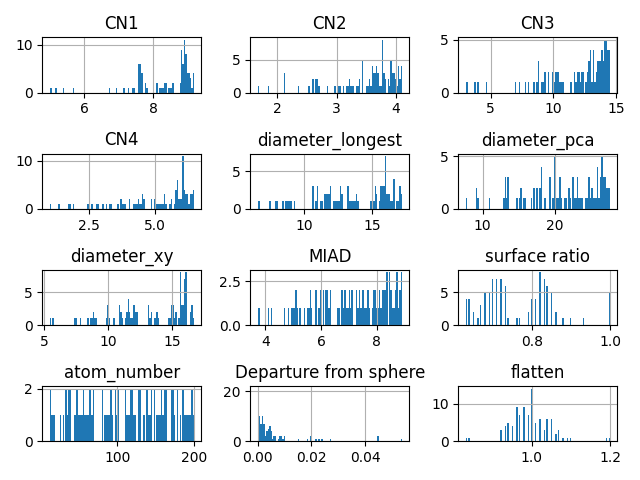

In [9]:
particles_descriptors=[]
bas=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

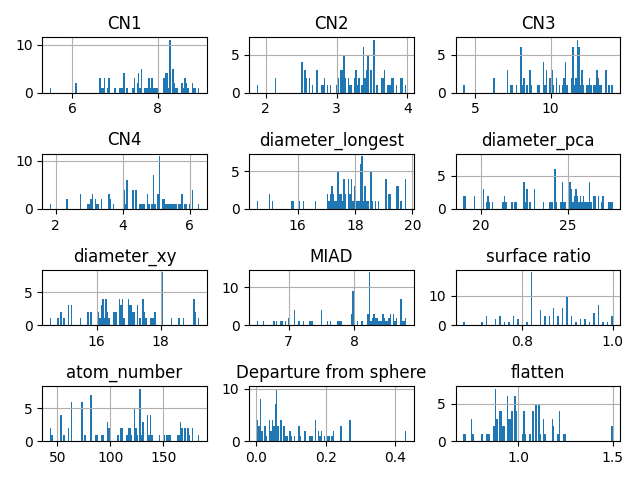

In [42]:
particles_descriptors=[]
bas=[]
for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [41]:
# [print(i,last_atom_list[i].symbols) for i in range(len(last_atom_list))]
view(last_atom_list[1])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

# new designs
1. using regular particles for the initial conditon.
2. check crossover particles(tuncation and adhesion). if the generated particle is not single one, then connect the particles.
3. mutation part: delete atoms which coordination number is less than 3, during random number of iterations.

In [5]:
#gauss
#making lattice
from tqdm.auto import tqdm
def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    # lattice=np.round(lattice-mid_position,6)
    closest_index=np.where(np.all(np.isclose(mid_position,lattice,rtol=lc/(2*np.sqrt(2))),axis=1))[0][0]
    lattice=lattice-lattice[closest_index]
    return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n_max,n_max,n_max,num_atoms)
# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # print(f"length={np.mean(lattice_big,axis=0)}")
    times=random.randint(1,3)

    #this is too strong
    while num_points<num_atoms*2:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-1),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-3),axis=1))[0])
    # print(len(particle),len(index))
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    #oblate set
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return (p-np.min(p))/(np.max(p)-np.min(p))

def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc,max_num_atoms)
        parent1=parent1_up+parent2_down
        parent2=parent2_up+parent1_down
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        parent1[parent1>1]=1
        parent2[parent2>1]=1
        return parent1,parent2
    else:
        return parent1,parent2
# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     num_atom1=parameter1[3]
#     num_atom2=parameter2[3]
#     min_num=min(num_atom1,num_atom2)

#     if random.random()<cross_over_rate:
#         crossover_point1=random.randint(1,min_num)
#         # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
#         # print(parent1)
#         # print(parent2)
#         # swith=random.choice([0,1])
#         return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:],parameter1,parameter2
#         # if swith==0:
#         #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
#         # if swith==1:
#         #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
#     else:
#         return parent1,parent2,parameter1,parameter2
def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    num_atoms=len(np.where(np.array(genome)==1)[0])
    if mr<=mutation_rate/2:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
    if mr>mutation_rate/2 and mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            genome_update=atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        
    else:
        genome_update=genome
    return genome_update
    
def atom_cut_up_down_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    closest_index=np.where(np.all(np.isclose(center,particle,rtol=lc/(1.8*np.sqrt(2))),axis=1))[0][0]
    particle_shift=particle-particle[closest_index]
    center=np.mean(particle_shift,axis=0)
    normal=normal_vector(center,theta,phi)
    
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle_shift:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=-lc/np.sqrt(2):
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=lc/np.sqrt(2):
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center_get=[]
    for i in range(len(particle)):
        CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
        if CN1==12:
            center_get.append(particle[i])
    if len(center_get)!=0:
        center=random.choice(center_get)
    else:
        return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,shell,lc,max_num_atoms):
    encodes=genome.copy()
    atom_num=len(np.where(encodes==1)[0])
    CN_steps=[]
    index_particle=[]
    zero_dict=dict()
    control=0
    while control<100:
        CNs1=[]
        dis1=[]
        index_particle=[]
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        for i in  range(len(big_lattice)):
            if encodes[i]==1:
                CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  dis<=np.round(np.sqrt(2)/2*lc,4) and CN1>4: 
                    index_particle.append(i)
                else:
                    encodes[i]=0
        
        for i in range(len(big_lattice)):     
            if encodes[i]==0:
                CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*lc,4):
                    zero_dict[i]=CN0
        zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
        residual=atom_num-len(index_particle)
        for i in range(residual):
            encodes[list(zero_dict.keys())[i]]=1
        # print(f"particle {j}")
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
        _,_,CN_ave=getCN_dis_N(atom,shell)
        control+=1
        CN_steps.append(CN_ave)
        if control>10:
            if CN_steps[-1]-CN_steps[-2]<1e-3:
                break
    return encodes
        

def genetic_algorithm():
    #1. set up parameters
    max_num_atoms=200
    generations=50
    population_size=500
    lc=3.77
    mutation_rate=0.3
    cross_over_rate=0.6
    shell=1
    descriptors={"surface ratio": 1,
                #  "flatten": 0.7,
                  "atom_number": 100
                # "CN1":6,
                # "CN2":1.5,
                # "CN3":2,
                # "CN4":5

    }
    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
       
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random

In [6]:
best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'surface ratio': 1, 'atom_number': 100}


  0%|          | 0/50 [00:00<?, ?it/s]

array([1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 0., 0.

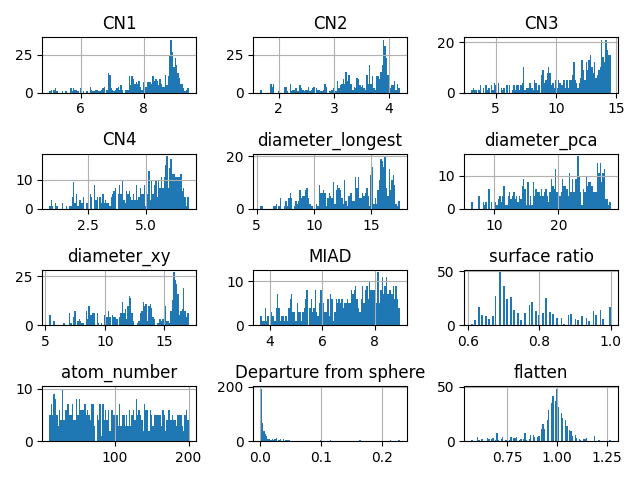

In [15]:
particles_descriptors=[]
bas=[]

for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

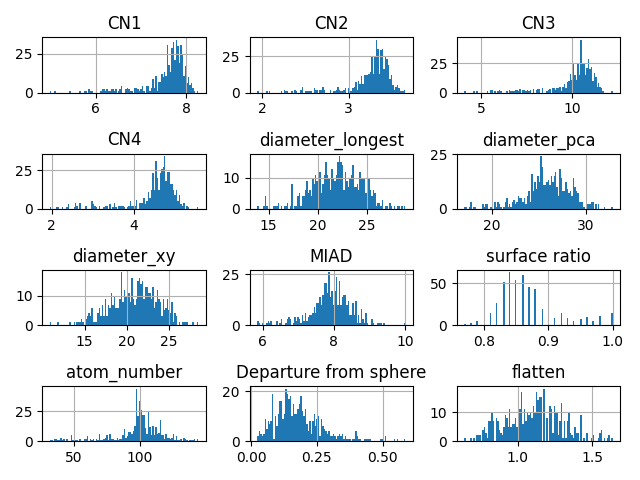

In [16]:
particles_descriptors=[]
bas=[]

for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

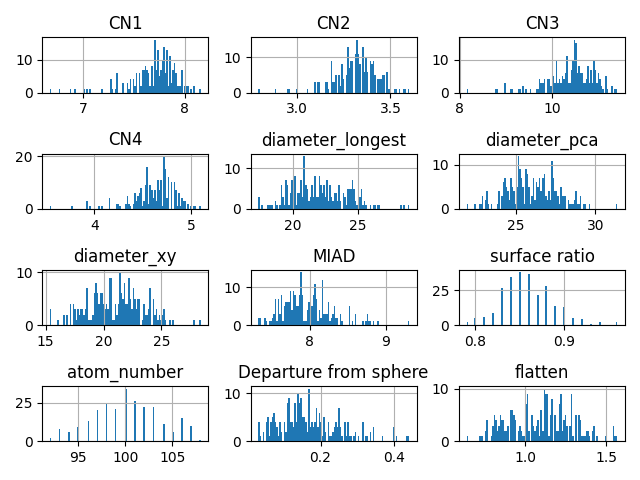

In [17]:
index=np.where(fitness_values<np.quantile(fitness_values,q=0.5))[0]
particles_descriptors=[]
bas=[]

for i in range(len(index)):
    particles_descriptors.append(descriptor_table(last_atom_list[index[i]]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [20]:
# view(last_atom_list[index[5]])
pdes[pdes["flatten"]<0.8]
view(last_atom_list[index[6]])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

[1124.8939308,
 963.6818596,
 886.0817216,
 876.6970048,
 853.7472833999999,
 852.267871,
 862.7196398,
 860.5245102000001,
 830.9119453999999,
 807.7005884,
 859.5303031999999,
 826.5111342000001,
 845.1149403999999]

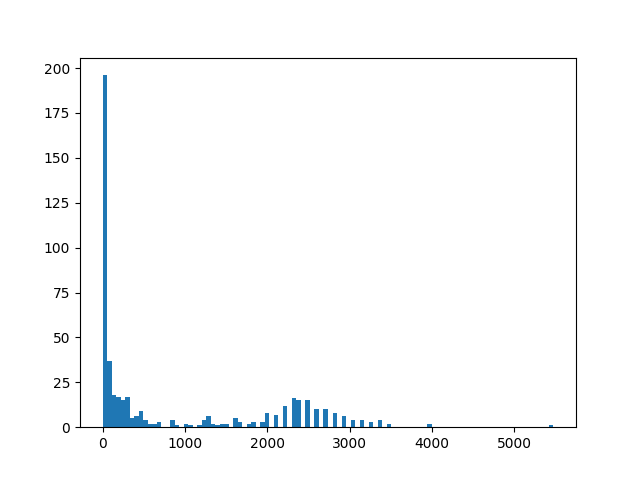

In [23]:
plt.figure()
plt.hist(fitness_values,bins=100)
fitness_record

In [19]:
pdes
view()

,CN1,CN2,CN3,CN4,diameter_longest,diameter_pca,diameter_xy,MIAD,surface ratio,atom_number,Departure from sphere,flatten
0,9.00,3.89,14.06,6.28,16.19,26.90,15.85,8.30,0.70,162,0.000723,1.00
1,9.04,3.92,14.18,6.42,16.24,26.86,15.80,8.40,0.70,168,0.002556,0.96
2,8.12,3.20,10.58,4.49,11.95,16.54,11.69,6.17,0.78,65,0.019015,0.97
3,8.85,3.82,13.34,5.96,15.70,23.33,15.24,7.87,0.72,137,0.003665,0.99
4,8.86,3.68,12.88,5.81,15.30,22.83,15.30,7.45,0.68,118,0.001197,1.04
...,...,...,...,...,...,...,...,...,...,...,...,...
495,7.69,3.38,10.31,4.47,11.77,18.11,11.62,6.20,0.81,64,0.006476,0.92
496,8.98,3.97,14.15,6.21,16.23,25.13,16.09,8.51,0.69,173,0.000267,1.00
497,7.89,3.47,10.89,4.61,11.94,19.59,11.94,6.42,0.81,72,0.006312,1.09
498,8.84,3.99,13.58,6.00,15.84,23.01,15.65,8.18,0.73,152,0.006691,1.00


In [34]:

#initial
max_num_atoms=200
generations=50
population_size=100
lc=3.77
mutation_rate=0.5
cross_over_rate=0.8
shell=1
descriptors={"surface ratio": 1,
             "flatten": 0.7,
                "atom_number": 100
            # "CN1":6,
            # "CN2":1.5,
            # "CN3":2,

}
print(descriptors)
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big=empty_lattice(lc,n_max,n_max,n_max)

#2. initialization of populations
populations,parameters = ini_population(lc=lc,
                            population_size=population_size,
                            max_num_atoms=max_num_atoms,
                            num_atoms=None)

{'surface ratio': 1, 'flatten': 0.7, 'atom_number': 100}


In [27]:
a=np.array([[0,0,1],[1,2,1],[3,3,3],[0,0,1]])
b=np.array([[0,0,1],[1,1,1],[3,2,2],[1,2,4]])
np.where(np.all(np.isclose(a,b[0],rtol=0.1),axis=1))[0][0]
b[0]

array([0, 0, 1])

In [28]:
# lattice_big=empty_lattice(lc,n_max,n_max,n_max)
# lattice=empty_lattice(lc,3,3,2)
# import matplotlib.pyplot as plt
# import numpy as np
# ax = plt.figure().add_subplot(projection='3d')
# pos=np.array(particle_collect[0])
# ax.scatter(lattice_big[:,0],lattice_big[:,1],lattice_big[:,2])
# ax.scatter(lattice[:,0],lattice[:,1],lattice[:,2],c='r')

In [10]:
particles_descriptors=[]
bas=[]

for i in range(len(populations)):
    particle,lattice=recon_coordfromcodes(populations[i],3.77,200)
    particle_collect.append(particle)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    particles_descriptors.append(descriptor_table(atom))
    atom_collect.append(atom)
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

NameError: name 'particle_collect' is not defined

In [35]:
fitness_record=[]
best_particle=[]
fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
new_populations = []
parents_get=[]
center_get=[]
normal_get=[]
generation=4
for _ in range(population_size//2):
    parent1=parents(populations,parameters,fitness_values)[0]
    parent2=parents(populations,parameters,fitness_values)[0]
    # print(parent1[0])
    children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
    children1,center1,normal1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
    children2,center2,normal2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
    center_get.extend([center1,center2])
    normal_get.extend([normal1,normal2])
    parents_get.extend([parent1,parent2])
    new_populations.extend([children1,children2])
# fitness_values=[]
# predict_values=[]
# for genome in new_populations:
#     # print(f"genome={genome}")
#     fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
#     fitness_values.append(fitness_cal[0])
#     predict_values.append(fitness_cal[1])
# # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
# #(3). find the best solution
# #[1]. best fitness value and prediction
# best_fitness=min(fitness_values)
# ave_fitness=np.mean(fitness_values)
# best_predict=predict_values[fitness_values.index(best_fitness)]
# best_index=fitness_values.index(best_fitness)
# #[2]. reconstruct the best solution from codes using new_populations.
# particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
# # best_clustering_energy=min(clustering_energy_values)
# #[3]. record the reconstructed particles using Atoms objects.
# best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
# fitness_record.append(ave_fitness)                         #dong
# #[4]. print output
# print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
# #[5]. update populations
# populations=new_populations


121 58 58
116 58 58
113 61 61
142 71 71
109 55 55
107 53 53
137 67 67
103 50 50
120 59 59
97 48 48
117 58 58
129 65 65
95 48 48
97 48 48
147 73 73
108 55 55
135 67 67
108 55 55
115 58 58
116 58 58
158 81 81
116 57 57
161 78 78
92 45 45
94 47 47
97 48 48
91 46 46
113 57 57
137 69 69
90 47 47
90 45 45
127 64 64
91 47 47
96 48 48
124 61 61
124 62 62
141 70 70
162 81 81
123 65 65
104 52 52
148 73 73
127 64 64
139 67 67
79 40 40
140 70 70
80 40 40
118 59 59
91 45 45


In [36]:
center_get

[array([-2.33677686,  0.29599174,  1.85384298]),
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 array([ 0.26   ,  0.21125, -0.79625]),
 array([-0.4170354 ,  0.91747788, -0.56716814]),
 [0, 0, 0],
 array([-1.89827465, -0.10619718,  1.97792254]),
 array([-1.50454128, -0.58798165,  0.05188073]),
 array([-1.30364486,  0.49327103, -0.10570093]),
 [0, 0, 0],
 array([-1.1420073 ,  0.0550365 ,  1.03193431]),
 [0, 0, 0],
 array([-2.28762136, -0.16470874, -1.93990291]),
 array([1.28808333, 1.837875  , 3.75429167]),
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 array([-1.43804124,  0.99108247,  1.6906701 ]),
 array([-1.32111111,  0.96666667,  1.96555556]),
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 array([3.50697674, 3.71155039, 3.77      ]),
 array([1.70642105, 1.84531579, 1.885     ]),
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 array([ 3.12871134,  3.65340206, -0.05829897]),
 array([-1.43619048,  0.84632653,  1.71829932]),
 array([-1.50101852,  0.9250463 ,  1.8675463 ]),
 [0, 0, 0],
 [0, 0, 0],
 [0, 0, 0],
 array

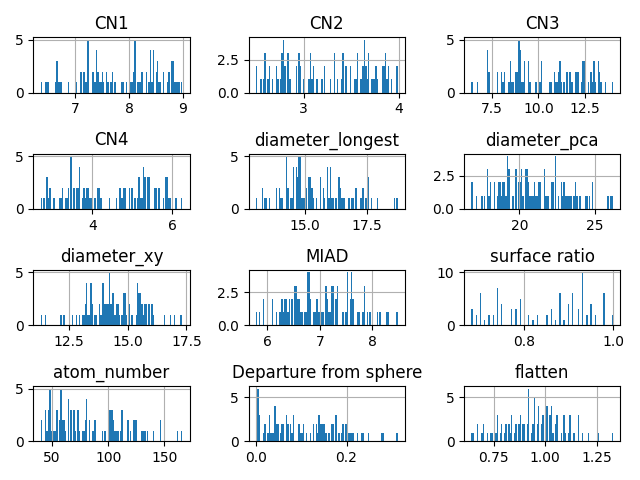

In [37]:
particles_descriptors=[]
particle_collect=[]
atom_collect=[]
bas=[]

for i in range(len(new_populations)):
    particle,lattice=recon_coordfromcodes(new_populations[i],3.77,200)
    particle_collect.append(particle)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    particles_descriptors.append(descriptor_table(atom))
    atom_collect.append(atom)
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

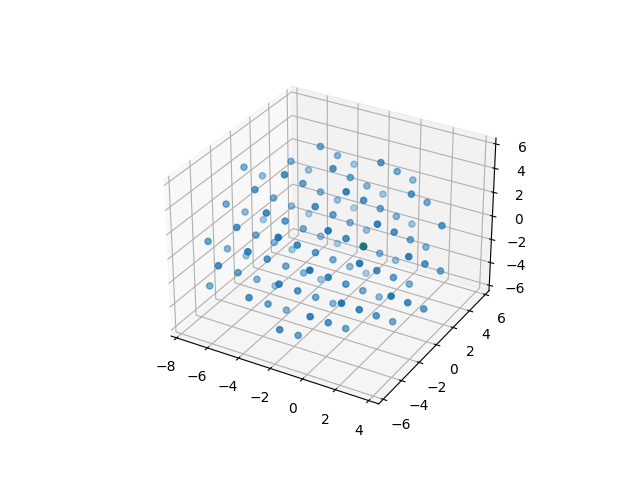

In [19]:
import matplotlib.pyplot as plt
import numpy as np
ax = plt.figure().add_subplot(projection='3d')
pos=np.array(particle_collect[3])
mean_position=center_get[3]
ax.scatter(pos[:,0],pos[:,1],pos[:,2])
ax.scatter(mean_position[0],mean_position[1],mean_position[2],c='r')
ax.scatter(normal_get[3][0],normal_get[3][1],normal_get[3][2],c='g')

In [32]:
pdes[pdes['flatten']<1]
view(atom_collect[7])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

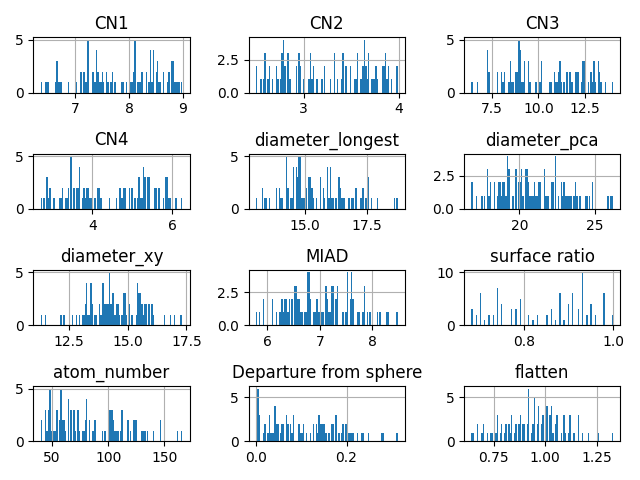

In [38]:
particles_descriptors=[]
particle_collect=[]
atom_collect=[]
bas=[]

for i in range(len(new_populations)):
    particle,lattice=recon_coordfromcodes(new_populations[i],3.77,200)
    particle_collect.append(particle)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    particles_descriptors.append(descriptor_table(atom))
    atom_collect.append(atom)
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [52]:
view(atom_collect[43])

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

In [40]:
for i in range(len(new_populations)):
    print(i,len(np.where(np.array(new_populations[i])==1)[0]))

0 58
1 123
2 103
3 161
4 58
5 61
6 135
7 71
8 55
9 53
10 120
11 67
12 103
13 50
14 59
15 104
16 81
17 81
18 48
19 58
20 146
21 105
22 112
23 112
24 65
25 48
26 86
27 84
28 102
29 48
30 73
31 55
32 140
33 118
34 109
35 67
36 55
37 58
38 123
39 125
40 58
41 81
42 57
43 78
44 45
45 125
46 132
47 102
48 47
49 105
50 77
51 48
52 101
53 84
54 150
55 112
56 46
57 57
58 69
59 106
60 118
61 89
62 101
63 101
64 47
65 45
66 75
67 73
68 146
69 64
70 47
71 97
72 48
73 61
74 95
75 87
76 62
77 70
78 81
79 65
80 131
81 111
82 52
83 73
84 130
85 64
86 67
87 102
88 124
89 166
90 80
91 89
92 40
93 80
94 70
95 124
96 107
97 40
98 59
99 45


In [122]:
for i in range(len(parents_get)):
    particle,lattice=recon_coordfromcodes(parents_get[i],3.77,200)
    particle_collect.append(particle)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    particles_descriptors.append(descriptor_table(atom))
    atom_collect.append(atom)


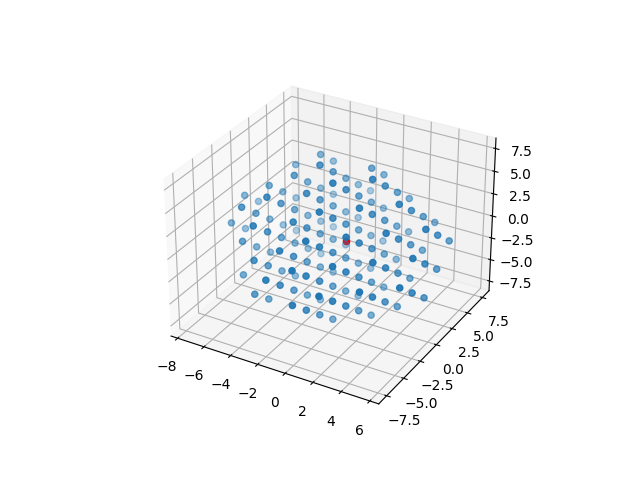

In [129]:
import matplotlib.pyplot as plt
import numpy as np
ax = plt.figure().add_subplot(projection='3d')
pos=np.array(particle_collect[0])
mean_position=center_get[0]
ax.scatter(pos[:,0],pos[:,1],pos[:,2])
ax.scatter(mean_position[0],mean_position[1],mean_position[2],c='r')
# ax.arrow(1,-0.00010,0,-0.00005, shape='full', lw=3, length_includes_head=True, head_width=.01)